# 03 - Limpieza de Datos
## Sistema de Predicción Temprana de Plagas - Sierra del Patlachique

**Objetivo:** Limpiar y tratar anomalías BASADO EN hallazgos del EDA

**Responsabilidades:**
- Auditoría de calidad (nulos, imposibilidades)
- Tratamiento de valores físicamente imposibles
- Imputación de missing values
- Tratamiento de outliers (si aplica)
- Verificación post-limpieza
- Exportar datos limpios

**NO hacer aquí:**
- Análisis exploratorio
- Cálculo de features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("Librerías cargadas")

# Cargar datos crudos
df = pd.read_csv("../data/raw/datos_patlachique_raw.csv", index_col='fecha', parse_dates=True)
print(f"Datos cargados: {df.shape}")

Librerías cargadas
Datos cargados: (817, 4)


## 1. AUDITORÍA DE CALIDAD

In [2]:
print("\n" + "="*70)
print("AUDITORÍA DE CALIDAD - DATOS CRUDOS")
print("="*70)

# Nulos
print("\nVALORES NULOS:")
nulos = df.isnull().sum()
print(nulos)
print(f"Total nulos: {nulos.sum()}")

# Imposibilidades físicas
print("\nVALORES FÍSICAMENTE IMPOSIBLES:")

# Temperatura
temp_bad = df[(df['temp_media_C'] > 45) | (df['temp_media_C'] < -10)]
print(f"Temperatura fuera de [-10°C, 45°C]: {len(temp_bad)} registros")

# Lluvia
lluvia_bad = df[df['lluvia_mm'] < 0]
print(f"Lluvia negativa: {len(lluvia_bad)} registros")

# Humedad suelo
hs_bad = df[(df['humedad_suelo_frac'] > 1) | (df['humedad_suelo_frac'] < 0)]
print(f"Humedad suelo fuera de [0, 1]: {len(hs_bad)} registros")

# Humedad relativa
hr_bad = df[(df['humedad_relativa_pct'] > 100) | (df['humedad_relativa_pct'] < 0)]
print(f"Humedad relativa fuera de [0%, 100%]: {len(hr_bad)} registros")

total_bad = len(temp_bad) + len(lluvia_bad) + len(hs_bad) + len(hr_bad)
print(f"\nTotal de anomalías detectadas: {total_bad}")


AUDITORÍA DE CALIDAD - DATOS CRUDOS

VALORES NULOS:
temp_media_C            0
lluvia_mm               0
humedad_suelo_frac      0
humedad_relativa_pct    0
dtype: int64
Total nulos: 0

VALORES FÍSICAMENTE IMPOSIBLES:
Temperatura fuera de [-10°C, 45°C]: 3 registros
Lluvia negativa: 3 registros
Humedad suelo fuera de [0, 1]: 3 registros
Humedad relativa fuera de [0%, 100%]: 3 registros

Total de anomalías detectadas: 12


## 2. TRATAMIENTO DE ANOMALÍAS

In [3]:
print("\n" + "="*70)
print("TRATAMIENTO DE DATOS")
print("="*70)

# Crear copia para limpiar
df_clean = df.copy()

# PASO 1: Reemplazar imposibilidades por NaN
print("\nPASO 1: Marcar imposibilidades como NaN")

df_clean.loc[(df_clean['temp_media_C'] > 45) | (df_clean['temp_media_C'] < -10), 'temp_media_C'] = np.nan
df_clean.loc[df_clean['lluvia_mm'] < 0, 'lluvia_mm'] = np.nan
df_clean.loc[(df_clean['humedad_suelo_frac'] > 1) | (df_clean['humedad_suelo_frac'] < 0), 'humedad_suelo_frac'] = np.nan
df_clean.loc[(df_clean['humedad_relativa_pct'] > 100) | (df_clean['humedad_relativa_pct'] < 0), 'humedad_relativa_pct'] = np.nan

print("\tImposibilidades reemplazadas por NaN")
print(f"\tNulos después: {df_clean.isnull().sum().sum()}")

# PASO 2: Imputación
print("\nPASO 2: Imputación de valores faltantes")
print("\tMétodo: Interpolación lineal (asume cambio gradual)")
print("\tJustificación: Variables climáticas cambian de forma continua")

df_clean = df_clean.interpolate(method='linear')

# Para nulos al inicio o final, usar forward fill y backward fill
df_clean = df_clean.ffill().bfill()

print(f"\tImputación completada")
print(f"\tNulos restantes: {df_clean.isnull().sum().sum()}")

if df_clean.isnull().sum().sum() == 0:
    print("\nDATOS 100% LIMPIOS Y CONTINUOS")


TRATAMIENTO DE DATOS

PASO 1: Marcar imposibilidades como NaN
	Imposibilidades reemplazadas por NaN
	Nulos después: 12

PASO 2: Imputación de valores faltantes
	Método: Interpolación lineal (asume cambio gradual)
	Justificación: Variables climáticas cambian de forma continua
	Imputación completada
	Nulos restantes: 0

DATOS 100% LIMPIOS Y CONTINUOS


## 3. VERIFICACIÓN POST-LIMPIEZA


VERIFICACIÓN POST-LIMPIEZA

Comparación Antes vs Después:

Variable                  Antes           Después        
-------------------------------------------------------
temp_media_C              0               0              
lluvia_mm                 0               0              
humedad_suelo_frac        0               0              
humedad_relativa_pct      0               0              

Estadísticas POST-LIMPIEZA:
       temp_media_C  lluvia_mm  humedad_suelo_frac  humedad_relativa_pct
count        817.00     817.00              817.00                817.00
mean          14.57       2.61                0.52                 64.15
std            2.79       4.31                0.16                 17.40
min            6.36       0.00                0.18                 18.42
25%           12.70       0.02                0.39                 49.44
50%           14.43       0.47                0.51                 68.44
75%           16.07       3.71                0.67    

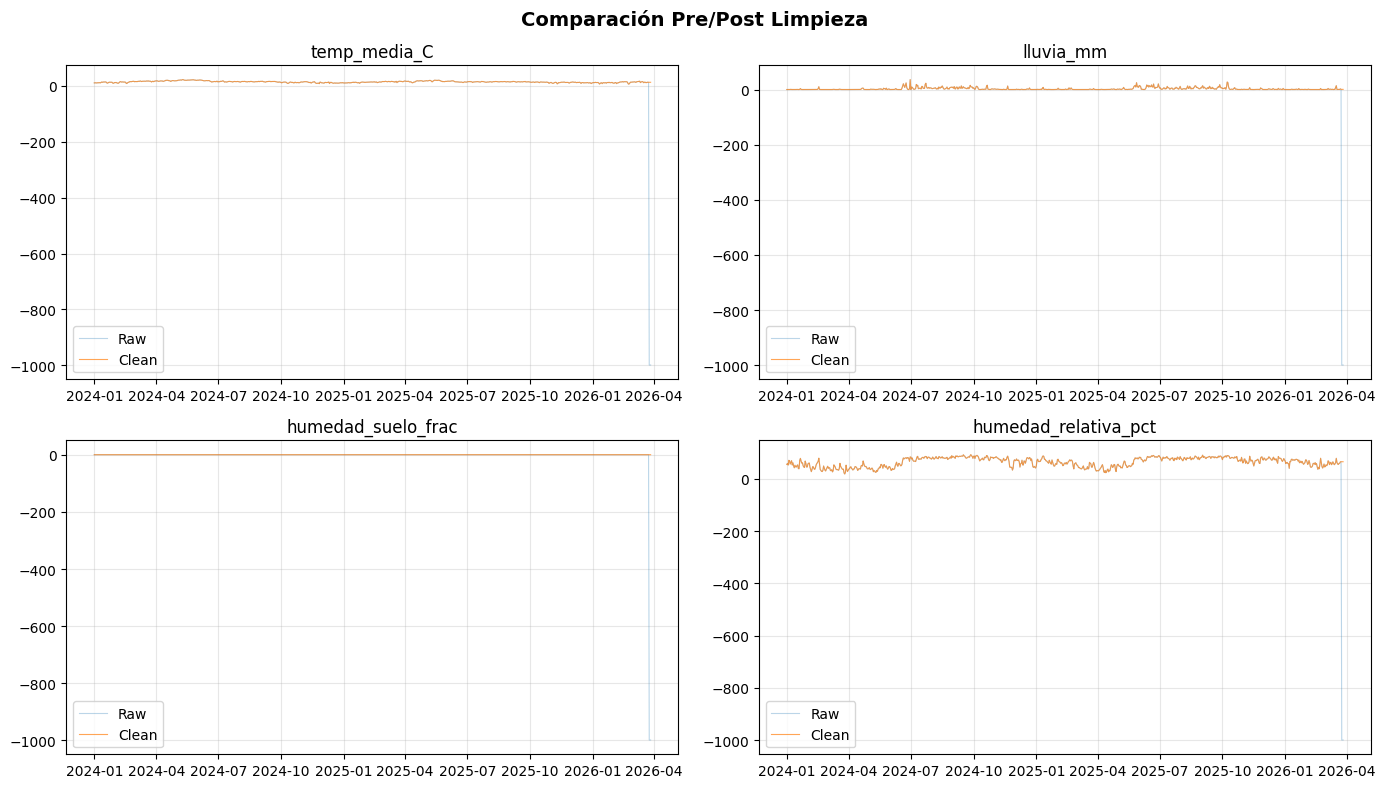


Gráfica guardada en reports/limpieza_antes_despues.png


In [4]:
print("\n" + "="*70)
print("VERIFICACIÓN POST-LIMPIEZA")
print("="*70)

print("\nComparación Antes vs Después:")
print(f"\n{'Variable':<25} {'Antes':<15} {'Después':<15}")
print("-"*55)

for col in df.columns:
    antes_nulos = df[col].isnull().sum()
    despues_nulos = df_clean[col].isnull().sum()
    print(f"{col:<25} {antes_nulos:<15} {despues_nulos:<15}")

print("\nEstadísticas POST-LIMPIEZA:")
print(df_clean.describe().round(2))

# Graficar antes y después
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Comparación Pre/Post Limpieza', fontsize=14, fontweight='bold')

cols = df.columns
for idx, col in enumerate(cols):
    ax = axes[idx // 2, idx % 2]
    ax.plot(df.index, df[col], alpha=0.3, label='Raw', linewidth=0.8)
    ax.plot(df_clean.index, df_clean[col], alpha=0.7, label='Clean', linewidth=0.8)
    ax.set_title(f'{col}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/reports/limpieza_antes_despues.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfica guardada en reports/limpieza_antes_despues.png")

## 4. EXPORTAR DATOS LIMPIOS

In [5]:
import os

# Crear directorio si no existe
os.makedirs("../data/processed", exist_ok=True)

# Guardar datos limpios
output_path = "../data/processed/datos_patlachique_clean.csv"
df_clean.to_csv(output_path, index=True, encoding='utf-8')

print(f"\nDatos limpios exportados")
print(f"\tRuta: {output_path}")
print(f"\tTamaño: {os.path.getsize(output_path) / 1024:.2f} KB")
print(f"\tRegistros: {len(df_clean)}")
print(f"\tSin nulos: ✅")

print("\n" + "="*70)
print("LIMPIEZA COMPLETADA")
print("="*70)
print("\nPróximo paso: Notebook 04 - Feature Engineering")
print("\tCrearemos indicadores de riesgo de plagas")
print("="*70)


Datos limpios exportados
	Ruta: ../data/processed/datos_patlachique_clean.csv
	Tamaño: 26.75 KB
	Registros: 817
	Sin nulos: ✅

LIMPIEZA COMPLETADA

Próximo paso: Notebook 04 - Feature Engineering
	Crearemos indicadores de riesgo de plagas
